In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Load dataset
df = pd.read_csv("../data/final/master_race_dataset.csv")

# Convert timestamp
df["collection_time"] = pd.to_datetime(df["collection_time"])

print(df.head())

  Pos.  No.      Class  Pro Rank      Name Laps         Gap       Last  \
0    1   80       SP 9  PRO    1  Schiller   36  ----LAP 36  12:08.277   
1  103   40       SP 9   AM   34   Strycek   29    7:38.118  12:08.336   
2  104  670  BMW M240i  NaN    6    Paviot   29   11:54.079  14:17.541   
3  105  454         V5  NaN    1    Hansen   29   13:19.925  14:03.894   
4  106  444         V5  NaN    2      Korn   28  ----LAP 28  10:50.752   

     Fastest Pit                Vehicle            collection_time  
0   8:14.337   5       Mercedes-AMG GT3 2026-05-17 00:15:14.030160  
1   8:53.859   4  BMW E89 Z4 (EVO 2013) 2026-05-17 00:15:14.030160  
2   9:58.466   5  BMW M240i Racing Cup* 2026-05-17 00:15:14.030160  
3  10:10.380   4   Porsche Cayman CM12* 2026-05-17 00:15:14.030160  
4   9:54.131   5   Porsche Cayman CM12* 2026-05-17 00:15:14.030160  


In [2]:
print("DATASET SHAPE:")
print(df.shape)

print("\nCOLUMN NAMES:")
print(df.columns)

print("\nMISSING VALUES:")
print(df.isnull().sum())

DATASET SHAPE:
(1280, 13)

COLUMN NAMES:
Index(['Pos.', 'No.', 'Class', 'Pro', 'Rank', 'Name', 'Laps', 'Gap', 'Last',
       'Fastest', 'Pit', 'Vehicle', 'collection_time'],
      dtype='str')

MISSING VALUES:
Pos.                 0
No.                  0
Class                0
Pro                560
Rank                 0
Name                 0
Laps                 0
Gap                 80
Last                 0
Fastest              0
Pit                  0
Vehicle              0
collection_time      0
dtype: int64


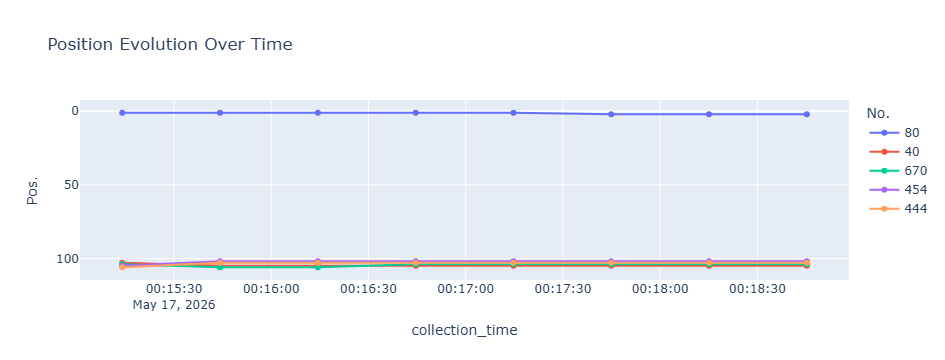

In [3]:
# Convert position to numeric
df["Pos."] = pd.to_numeric(df["Pos."], errors="coerce")

# Top 5 cars
top_cars = df["No."].unique()[:5]

filtered_df = df[df["No."].isin(top_cars)]

fig = px.line(
    filtered_df,
    x="collection_time",
    y="Pos.",
    color="No.",
    title="Position Evolution Over Time",
    markers=True
)

# Lower position number = better
fig.update_yaxes(autorange="reversed")

fig.show()

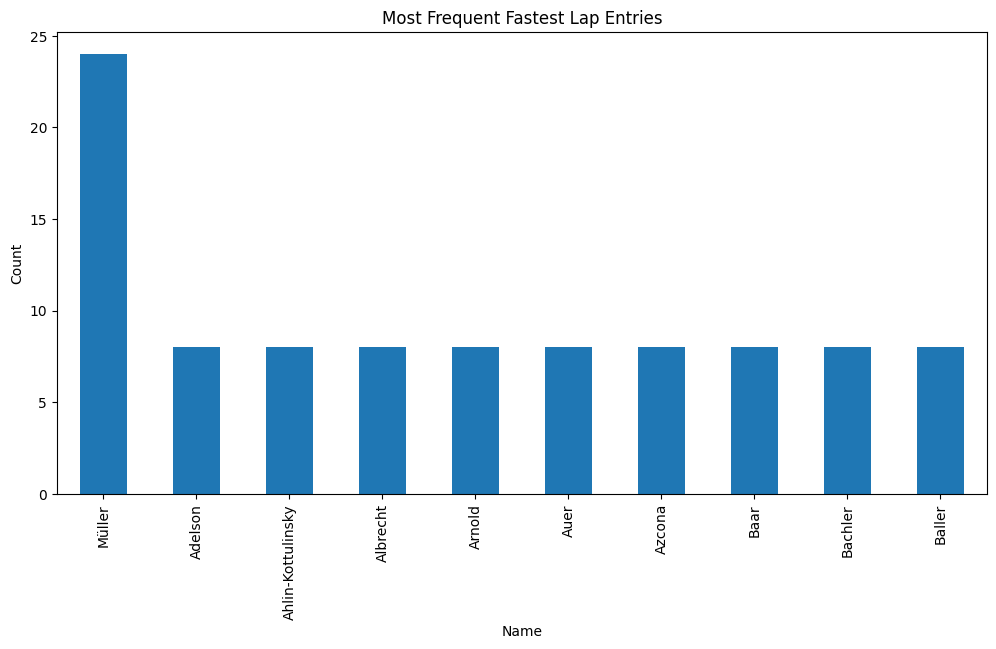

In [4]:
fastest_counts = (
    df.groupby("Name")["Fastest"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

fastest_counts.plot(
    kind="bar",
    figsize=(12, 6),
    title="Most Frequent Fastest Lap Entries"
)

plt.ylabel("Count")
plt.show()

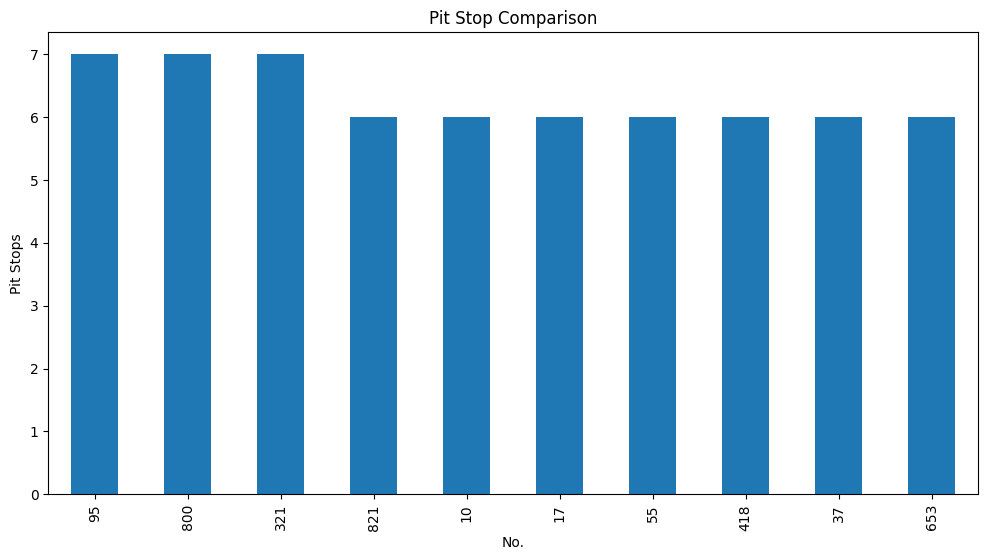

In [5]:
df["Pit"] = pd.to_numeric(df["Pit"], errors="coerce")

pit_analysis = (
    df.groupby("No.")["Pit"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

pit_analysis.plot(
    kind="bar",
    figsize=(12, 6),
    title="Pit Stop Comparison"
)

plt.ylabel("Pit Stops")
plt.show()

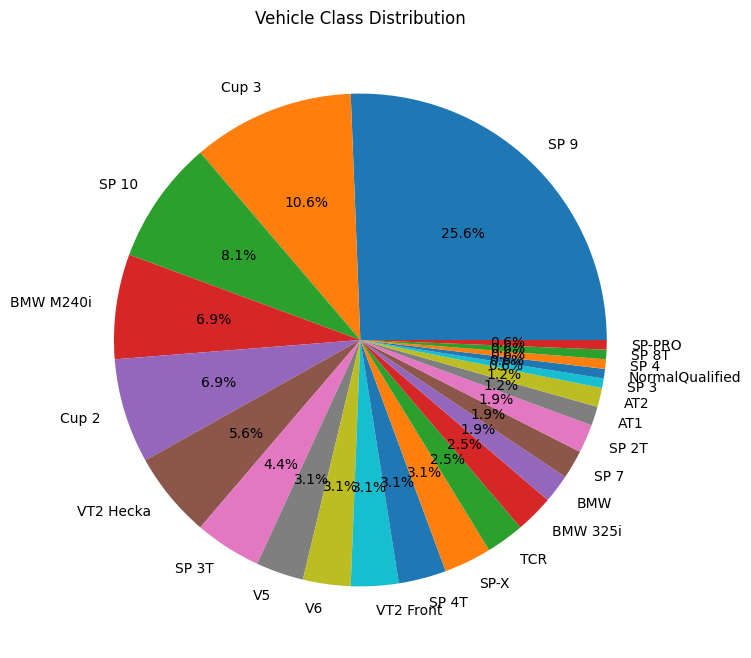

In [6]:
class_counts = df["Class"].value_counts()

class_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8, 8),
    title="Vehicle Class Distribution"
)

plt.ylabel("")
plt.show()